# se-dat walkthrough — Titanic dataset

`se-dat` (Simple Exploratory Data Analysis) takes a raw DataFrame and gives you:

1. **Column type profiling** — inferred semantic types, missing %, cardinality, confidence flags.
2. **Correlation analysis** — Pearson/Spearman (numeric), Cramér's V (categorical), correlation ratio η (mixed), heatmaps, multicollinearity flags.
3. **Encoding suggestions** — binary maps for `yes/no` style columns, one-hot for low-cardinality categoricals, target/ordinal encoding for high-cardinality ones.
4. **Missing-value handling** — per-column imputation plans (median / mode / drop).
5. **Outlier detection** — IQR and z-score flags surfaced right in the profile table.
6. **Artifacts & interop** — static one-file HTML reports and scikit-learn `ColumnTransformer`s.

Available on PyPI: [`pip install se-dat`](https://pypi.org/project/se-dat/)

This notebook runs the whole pipeline on the classic Titanic passenger data.

In [37]:
# If you haven't installed the package yet, uncomment:
# %pip install se-dat[sklearn]

## 1. Load the data

In [38]:
import pandas as pd
import sedat

print("se-dat version:", sedat.__version__)

URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)
df.head()

se-dat version: 0.1.0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [39]:
print(f"{df.shape[0]} rows x {df.shape[1]} columns")
df.describe(include="all").T

891 rows x 12 columns


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


What we already know going in:

- `Survived` (0/1) is our prediction target.
- `Age` has missing values, `Cabin` is mostly missing.
- `Sex` and `Embarked` are strings, `Pclass` is a number but really an ordinal category,
- `Name`, `Ticket`, `PassengerId` are high-cardinality text/ids.

Let's see how much of that `se-dat` recovers automatically.

## 2. One-call report: `EDAReport.create`

The facade runs profiling, correlations and encoding suggestions in one shot.
Passing `target=` enables target-encoding suggestions for high-cardinality categoricals.

In [40]:
report = sedat.EDAReport.create(df, target=df["Survived"])

In [41]:
report.profile.summary

,dtype,inferred_type,missing_pct,n_unique,cardinality_ratio,confidence,outliers,notes
column,,,,,,,,
PassengerId,int64,id,0.00,891,1.0000,high,,high-cardinality unique integer values
Survived,int64,boolean,0.00,2,0.0022,medium,,numeric 0/1 column: ambiguous boolean vs numeric
Pclass,int64,numeric,0.00,3,0.0034,high,,
Name,str,string,0.00,891,1.0000,high,,high-cardinality free text
Sex,str,categorical,0.00,2,0.0022,high,,
Age,float64,numeric,19.87,88,0.1232,high,Age: 11 potential outliers (1.5%),
SibSp,int64,numeric,0.00,7,0.0079,high,SibSp: 46 potential outliers (5.2%),
Parch,int64,numeric,0.00,7,0.0079,high,Parch: 213 potential outliers (23.9%),
Ticket,str,string,0.00,681,0.7643,high,,many unique values


Things to notice in the profile:

- `PassengerId` was recognized as an **id** column (unique integers).
- `Survived` (int 0/1) is flagged **boolean** with *medium* confidence — 0/1 is ambiguous between a flag and a real number.
- `Age` shows its **missing_pct**, `Cabin` shows ~77% missing.
- `Sex`, `Embarked` land in **categorical**; `Name`/`Ticket` in **string** (high-cardinality free text).- The **outliers** column notes numeric columns with values outside IQR fences — `Fare` has a handful of extreme ticket prices.

In [42]:
report.correlations.flagged_pairs

,column_a,column_b,kind,method,value,flagged
45,Ticket,Cabin,categorical,cramers_v,0.7939,True
48,Age,Cabin,numeric-categorical,eta,0.9192,True
50,Age,Name,numeric-categorical,eta,1.0000,True
52,Age,Ticket,numeric-categorical,eta,0.8851,True
53,Fare,Cabin,numeric-categorical,eta,0.9409,True
55,Fare,Name,numeric-categorical,eta,1.0000,True
57,Fare,Ticket,numeric-categorical,eta,1.0000,True
58,Parch,Cabin,numeric-categorical,eta,0.9699,True
60,Parch,Name,numeric-categorical,eta,1.0000,True
62,Parch,Ticket,numeric-categorical,eta,0.9063,True


In [43]:
report.encoding_summary

,column,current_type,suggested_type,strategy,cardinality,rationale
0,Sex,categorical,boolean (0/1),binary_encode,2,two distinct values: binary encode
1,Embarked,categorical,one-hot (dummy) columns,one_hot,3,low-cardinality categorical (k=3)


## 3. Profiling, piece by piece

Everything in the report is also available as standalone functions.

In [44]:
profile = sedat.profile_dataframe(df)
profile.summary

,dtype,inferred_type,missing_pct,n_unique,cardinality_ratio,confidence,outliers,notes
column,,,,,,,,
PassengerId,int64,id,0.00,891,1.0000,high,,high-cardinality unique integer values
Survived,int64,boolean,0.00,2,0.0022,medium,,numeric 0/1 column: ambiguous boolean vs numeric
Pclass,int64,numeric,0.00,3,0.0034,high,,
Name,str,string,0.00,891,1.0000,high,,high-cardinality free text
Sex,str,categorical,0.00,2,0.0022,high,,
Age,float64,numeric,19.87,88,0.1232,high,,
SibSp,int64,numeric,0.00,7,0.0079,high,,
Parch,int64,numeric,0.00,7,0.0079,high,,
Ticket,str,string,0.00,681,0.7643,high,,many unique values


In [45]:
# Inspect inference on individual, tricky columns
for col in ["PassengerId", "Survived", "Cabin"]:
    print(f"--- {col} ---")
    print(sedat.infer_column_type(df[col]), end="\n\n")

--- PassengerId ---
{'n_non_null': 891, 'n_unique': 891, 'missing_pct': 0.0, 'cardinality_ratio': 1.0, 'inferred_type': 'id', 'confidence': 'high', 'notes': ['high-cardinality unique integer values']}

--- Survived ---
{'n_non_null': 891, 'n_unique': 2, 'missing_pct': 0.0, 'cardinality_ratio': 0.0022, 'inferred_type': 'boolean', 'confidence': 'medium', 'notes': ['numeric 0/1 column: ambiguous boolean vs numeric']}

--- Cabin ---
{'n_non_null': 204, 'n_unique': 147, 'missing_pct': 77.1, 'cardinality_ratio': 0.7206, 'inferred_type': 'string', 'confidence': 'high', 'notes': ['many unique values']}



## 4. Correlation analysis

`se-dat` covers three pairings:

| pairing | measure | function |
|---|---|---|
| numeric ↔ numeric | Pearson / Spearman | `numeric_correlation` |
| categorical ↔ categorical | Cramér's V | `categorical_correlation` |
| numeric ↔ categorical | correlation ratio η | `numeric_categorical_correlation` |

In [46]:
pearson = sedat.numeric_correlation(df, method="pearson")
pearson

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


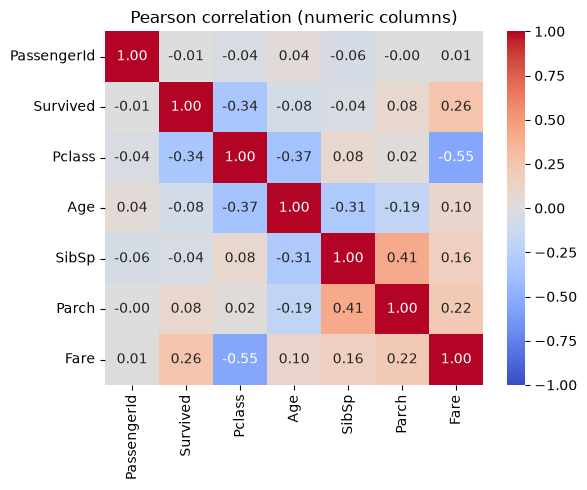

In [47]:
fig = sedat.correlation_heatmap(pearson, title="Pearson correlation (numeric columns)");

### Spearman (rank-based)

`Pclass` vs `Fare` is stronger under Spearman than Pearson — the fare distribution is heavily skewed, so ranks tell a cleaner story.

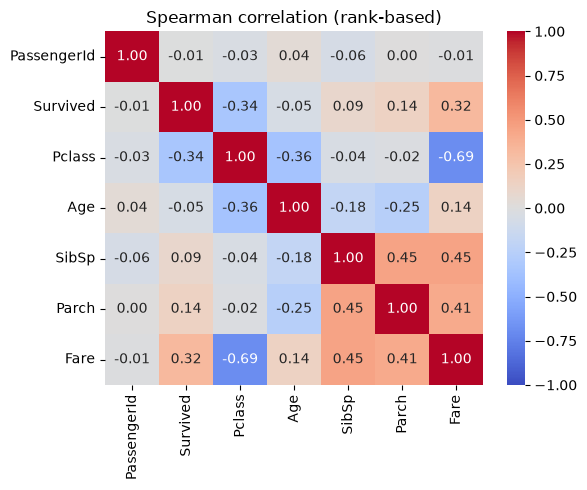

In [48]:
spearman = sedat.numeric_correlation(df, method="spearman")
fig = sedat.correlation_heatmap(spearman, title="Spearman correlation (rank-based)");

### Cramér's V (categorical ↔ categorical)

> Caveat: Cramér's V is biased upward for high-cardinality columns, so take the `Ticket`/`Cabin` numbers with a grain of salt — `Sex` vs `Embarked` is the meaningful cell here.

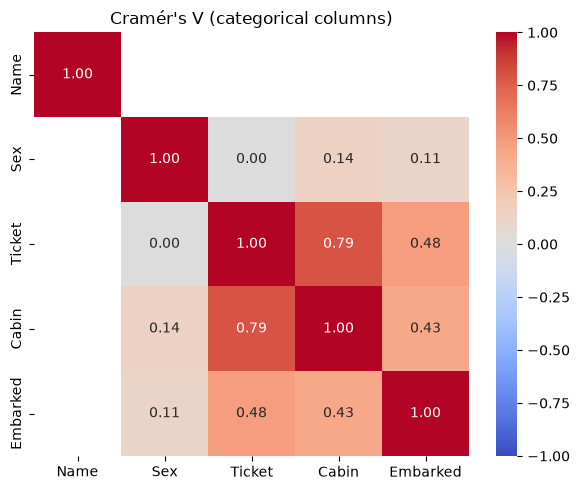

In [49]:
cramers = sedat.categorical_correlation(df)
fig = sedat.correlation_heatmap(cramers, title="Cramér's V (categorical columns)");

In [50]:
# Correlation ratio: how well does each categorical column explain each numeric column?
eta = sedat.numeric_categorical_correlation(df)
eta.round(3)

categorical,Cabin,Embarked,Name,Sex,Ticket
numeric,,,,,
Age,0.919,0.042,1.0,0.093,0.885
Fare,0.941,0.282,1.0,0.182,1.000
Parch,0.970,0.085,1.0,0.245,0.906
PassengerId,0.897,0.034,1.0,0.043,0.876
Pclass,1.000,0.308,1.0,0.132,1.000
SibSp,0.964,0.070,1.0,0.115,0.948
Survived,0.889,0.173,1.0,0.543,0.928


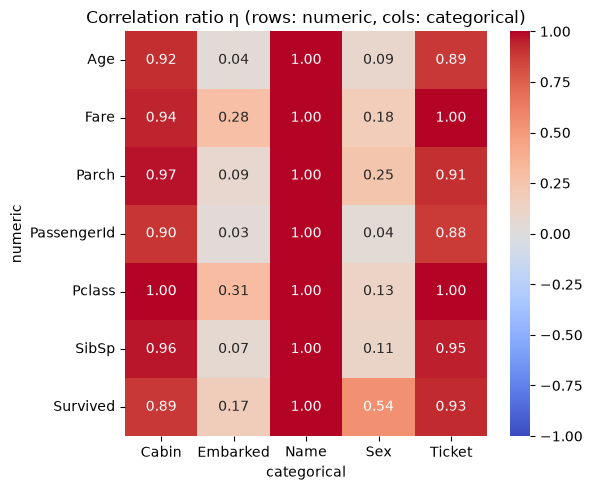

In [51]:
fig = sedat.correlation_heatmap(eta, title="Correlation ratio η (rows: numeric, cols: categorical)");

In [52]:
# Pairs above the |0.7| threshold — potential multicollinearity
sedat.correlation_report(df, threshold=0.7).flagged_pairs

,column_a,column_b,kind,method,value,flagged
45,Ticket,Cabin,categorical,cramers_v,0.7939,True
48,Age,Cabin,numeric-categorical,eta,0.9192,True
50,Age,Name,numeric-categorical,eta,1.0000,True
52,Age,Ticket,numeric-categorical,eta,0.8851,True
53,Fare,Cabin,numeric-categorical,eta,0.9409,True
55,Fare,Name,numeric-categorical,eta,1.0000,True
57,Fare,Ticket,numeric-categorical,eta,1.0000,True
58,Parch,Cabin,numeric-categorical,eta,0.9699,True
60,Parch,Name,numeric-categorical,eta,1.0000,True
62,Parch,Ticket,numeric-categorical,eta,0.9063,True


## 5. Encoding suggestions

Strategies chosen per column:

| situation | strategy |
|---|---|
| binary-like strings (`yes/no`) | `binary_encode` → 0/1 |
| categorical with ≤ `cardinality_threshold` values | `one_hot` |
| high-cardinality categorical **with** target | `target_encode` |
| high-cardinality categorical **without** target | `ordinal_encode` (warns) |

On Titanic that means: `Sex` → binary map, `Embarked` → one-hot. Everything else is left alone.

In [53]:
plan = sedat.suggest_encodings(df, target=df["Survived"], cardinality_threshold=10)
plan.summary

,column,current_type,suggested_type,strategy,cardinality,rationale
0,Sex,categorical,boolean (0/1),binary_encode,2,two distinct values: binary encode
1,Embarked,categorical,one-hot (dummy) columns,one_hot,3,low-cardinality categorical (k=3)


### Applying a single suggestion

You don't have to accept everything — pick suggestions individually:

In [54]:
sex_step = next(s for s in plan.suggestions if s.column == "Sex")
step_df = sex_step.apply(df)

step_df[["Sex", "Embarked"]].head()

,Sex,Embarked
0,1,S
1,0,C
2,0,S
3,0,S
4,1,S


### Applying everything at once

`apply_all_encodings` returns a new frame — the original `df` is never mutated.

In [55]:
model_ready = report.apply_all_encodings()
model_ready.dtypes.to_frame("dtype")

,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64


In [56]:
model_ready.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,0,0,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,0,0,1


## 6. Missing-value handling

`suggest_imputations` returns an `ImputationPlan` with one suggestion per incomplete column:

- **numeric** -> median fill (the rationale mentions the mean as an alternative),
- **categorical/boolean-like** -> mode fill,
- anything missing above a configurable threshold (default 50%) -> **drop the column** instead of inventing data.

On Titanic that means: `Age` gets the median, `Embarked` gets the mode, and `Cabin` (~77% missing) is recommended for dropping.

In [57]:
imp_plan = sedat.suggest_imputations(df)
imp_plan.summary

,column,current_type,strategy,n_missing,missing_pct,fill_value,rationale
0,Age,numeric,median,177,19.87,28.0,numeric column: median is robust to outliers (...
1,Cabin,string,drop_column,687,77.10,None,77.1% missing (above 50% threshold): dropping ...
2,Embarked,categorical,mode,2,0.22,S,categorical column: fill with the most frequen...


In [58]:
# one column at a time...
filled = imp_plan.apply(df, column="Age")
print("Age median used:", imp_plan.get("Age").fill_value)

# ...or everything at once — also available as report.apply_all_imputations()
complete = report.apply_all_imputations()
complete.isna().sum().to_frame("missing_after")

Age median used: 28.0


,missing_after
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## 7. Outlier detection

`detect_outliers` works over numeric columns with two methods:
`"iqr"` (default, values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`) and
`"zscore"` (|z| > 3). It reports per-column counts and percentages plus the
flagged row labels. `EDAReport.create` already runs it for you and shows a
one-line note per column in `report.profile.summary`.

In [59]:
outliers = sedat.detect_outliers(df, method="iqr", iqr_scale=1.5)
outliers.summary.round(2)

,column,method,outlier_count,outlier_pct,lower_bound,upper_bound,note
0,PassengerId,iqr,0,0.00,-444.00,1336.00,
1,Survived,iqr,0,0.00,-1.50,2.50,
2,Pclass,iqr,0,0.00,0.50,4.50,
3,Age,iqr,11,1.54,-6.69,64.81,Age: 11 potential outliers (1.5%)
4,SibSp,iqr,46,5.16,-1.50,2.50,SibSp: 46 potential outliers (5.2%)
5,Parch,iqr,213,23.91,0.00,0.00,Parch: 213 potential outliers (23.9%)
6,Fare,iqr,116,13.02,-26.72,65.63,Fare: 116 potential outliers (13.0%)


In [60]:
fare = outliers.get("Fare")
print(f"Fare fences: ({fare.lower:.2f}, {fare.upper:.2f})")
df.loc[fare.indices, ["Fare"]].head()

Fare fences: (-26.72, 65.63)


,Fare
1,71.2833
27,263.0000
31,146.5208
34,82.1708
52,76.7292


## 8. One-file HTML report

`report.to_html(path)` writes a static, self-contained page — every summary
table plus the correlation heatmaps embedded as base64 PNGs. Inline CSS only,
no JavaScript, no external assets: easy to e-mail or drop next to your repo.

In [61]:
import os

out_path = report.to_html("titanic_eda_report.html")
print(f"wrote {out_path} ({os.path.getsize(out_path):,} bytes)")

# To view it inside Jupyter:
# from IPython.display import IFrame
# IFrame(out_path, width=1000, height=600)

wrote titanic_eda_report.html (273,175 bytes)


## 9. scikit-learn interop

`EncodingPlan.to_column_transformer()` mirrors the suggested encodings with
native sklearn transformers — `OrdinalEncoder` for binary maps,
`OneHotEncoder` for low-cardinality categoricals, `TargetEncoder` for
high-cardinality ones — while already-numeric columns pass through.

The payoff vs. applying encodings by hand: fit on a training frame, then
`.transform()` a test frame and unseen categories are handled gracefully
(all-zeros / `-1`) instead of crashing or changing the output shape.
Requires the optional extra: `%pip install se-dat[sklearn]`.

In [62]:
try:
    ct = plan.to_column_transformer()
except ImportError as exc:
    print(exc)  # scikit-learn not installed
else:
    features = df.drop(columns=["Survived"])
    Xt = ct.fit_transform(features, df["Survived"])
    print(f"transformer: {type(ct).__name__}")
    transformed = pd.DataFrame(Xt, columns=ct.get_feature_names_out())
    transformed.head()

transformer: ColumnTransformer


## 10. Datetime feature extraction

`suggest_datetime_features` proposes calendar features for every detected
datetime column: year, month, day, day-of-week (`_dow`, Monday=0),
`_is_weekend` — plus `_hour` only when the data actually contains a time
component. The Titanic CSV has no date column, so we demo on a small
synthetic one:

In [63]:
flights = pd.DataFrame(
    {
        "departure": pd.to_datetime(
            [
                "2024-01-06 08:30",   # Saturday
                "2024-01-08 19:45",   # Monday
                "2024-02-10 06:00",
                None,
            ]
        )
    }
)

dt_plan = sedat.suggest_datetime_features(flights)
dt_plan.summary

,column,n_features,features,has_time_component,new_columns
0,departure,6,"year, month, day, day_of_week, is_weekend, hour",True,"departure_year, departure_month, departure_day..."


In [64]:
featurized = sedat.apply_datetime_features(flights)
# nullable Int64 columns: missing timestamps stay <NA> instead of sentinels
featurized[["departure", "departure_dow", "departure_is_weekend", "departure_hour"]]

,departure,departure_dow,departure_is_weekend,departure_hour
0,2024-01-06 08:30:00,5,1,8
1,2024-01-08 19:45:00,0,0,19
2,2024-02-10 06:00:00,5,1,6
3,NaT,<NA>,<NA>,<NA>


## 11. Save & load plans

Plans serialize their *decisions* (categories, fill values, code mappings) to
JSON — not function references — so a plan fitted on training data can be
re-applied to new data later with identical semantics: stable one-hot schema,
frozen binary/ordinal codes, stored target means.

We fit on the first 700 passengers, then transform a test slice that
deliberately lacks one `Embarked` category.

In [65]:
train_df = df.iloc[:700]
train_plan = sedat.suggest_encodings(train_df, target=train_df["Survived"])
train_plan.save("titanic_encoding_plan.json")

# imputation and datetime plans expose the same .save()/.load() API:
# sedat.suggest_imputations(df).save("imputation_plan.json")
# sedat.EncodingPlan.load / sedat.ImputationPlan.load / sedat.DatetimeFeaturePlan.load

'titanic_encoding_plan.json'

In [66]:
loaded = sedat.EncodingPlan.load("titanic_encoding_plan.json")

test_df = df.iloc[700:].copy()
test_df = test_df[test_df["Embarked"] != "Q"]  # category absent in this slice

encoded_test = loaded.apply_all(test_df.drop(columns=["Survived"]))
print("schema:", list(encoded_test.columns))

# 'Q' never appears here, yet the dummy column exists — filled with zeros:
encoded_test[["Embarked_S", "Embarked_C", "Embarked_Q"]].sum()

schema: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


Embarked_S    142
Embarked_C     34
Embarked_Q      0
dtype: int64

## 12. Bonus: feed it straight into a model

Sanity check that the transformed frame is genuinely model-ready (needs `scikit-learn`).

In [67]:
try:
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    from sklearn.pipeline import make_pipeline
except ImportError:
    print("scikit-learn not installed — skipping this cell (%pip install scikit-learn to run it).")
else:
    X = (
        model_ready
        .drop(columns=["Survived"])
        .select_dtypes("number")
        .drop(columns=["PassengerId"])
    )
    y = model_ready["Survived"]

    pipe = make_pipeline(SimpleImputer(strategy="median"), LogisticRegression(max_iter=1000))
    scores = cross_val_score(pipe, X, y, cv=5)
    print(f"LogisticRegression 5-fold CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

LogisticRegression 5-fold CV accuracy: 0.790 ± 0.019


## Wrap-up

The full loop in a few lines:

```python
import sedat

report = sedat.EDAReport.create(df, target=df["Survived"])
report.profile.summary                 # what did I load? (+ outlier notes)
report.correlations.flagged_pairs      # what's redundant?
report.imputation_summary              # what's missing & how to fix it
report.outliers.summary                # which values look extreme
model_ready = report.apply_all_encodings()   # make it trainable
clean      = report.apply_all_imputations()  # close the gaps
report.to_html("eda_report.html")       # shareable artifact
plan.to_column_transformer()            # drop into an sklearn Pipeline
sedat.suggest_datetime_features(df)     # calendar features for date columns
plan.save("plan.json")                  # reproducible train/test transforms
```

See the README for the complete API (`profile_column`, `cramers_v`, `correlation_ratio`, ...).